# Asset Pricing - Estudio de Eventos

* Universidad de Chile

* Franco Mansilla Ibáñez (www.francomansilla.com)

# 1. Instalación de Librería

In [1]:
pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.5/94.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd

from linearmodels.panel import PanelOLS
from linearmodels.panel import compare
import statsmodels.api as sm

import matplotlib.pyplot as plt
import matplotlib.dates as mdates


$ presión_{i,t,f} = \sum \frac{\Delta Q_{i,t,f}}{Q_{i,t-1,f}} $

* Cantidad de acciones (Q) del activo $i$ en el tiempo $t$ en la AFP $f$

In [6]:
# Ruta más simple del archivo
ruta_archivo = "/content/BD. Estudio de Eventos.csv"

# Carga del archivo CSV
df = pd.read_csv(ruta_archivo)

# Muestra las primeras filas del DataFrame
print("Número de Columnas:", len(df.columns))
print("Número de Filas:", len(df))

df.head()

Número de Columnas: 8
Número de Filas: 6862


,fecha,accion,mcap,retorno,presion3,mom,vol,btm
0,12/2002,AESGENER,19.379826,-0.115385,0.0,NaN,NaN,NaN
1,01/2003,AESGENER,19.357848,-0.021739,0.0,-0.021739,NaN,NaN
2,02/2003,AESGENER,19.312385,-0.044444,0.0,-0.066184,0.016055,NaN
3,03/2003,AESGENER,19.240065,-0.069767,0.0,-0.135951,0.024026,NaN
4,04/2003,AESGENER,19.401333,0.175000,0.0,0.039049,0.111892,NaN


# 2. Declaración Panel

In [7]:
# Convertir 'fecha' a datetime y establecer como índice junto con 'accion'
df['fecha'] = pd.to_datetime(df['fecha'], format='%m/%Y')
df.set_index(['accion', 'fecha'], inplace=True)

df.head()

mcap   retorno  presion3       mom       vol  btm
accion   fecha                                                             
AESGENER 2002-12-01  19.379826 -0.115385       0.0       NaN       NaN  NaN
         2003-01-01  19.357848 -0.021739       0.0 -0.021739       NaN  NaN
         2003-02-01  19.312385 -0.044444       0.0 -0.066184  0.016055  NaN
         2003-03-01  19.240065 -0.069767       0.0 -0.135951  0.024026  NaN
         2003-04-01  19.401333  0.175000       0.0  0.039049  0.111892  NaN

# 3. Modelo de Regresión por Panel

In [8]:
# Filtrar las fechas según tu condición
start_date = "2004-02-01"
end_date = "2006-12-01"
mask = (df.index.get_level_values('fecha') >= start_date) & (df.index.get_level_values('fecha') <= end_date)
df_filtrado = df.loc[mask]

df_filtrado

mcap   retorno  presion3       mom       vol  \
accion   fecha                                                           
AESGENER 2004-02-01  20.204002  0.235578       NaN  0.416079  0.161505   
         2004-03-01  19.993836 -0.189550       0.0  0.102779  0.176186   
         2004-04-01  19.957904 -0.035294       0.0 -0.121502  0.177737   
         2004-05-01  20.076469  0.001125       0.0 -0.149473  0.135081   
         2004-06-01  20.147087  0.073171       0.0 -0.053575  0.135410   
...                        ...       ...       ...       ...       ...   
ZOFRI    2006-08-01  18.093927 -0.009091       0.0  0.422199  0.077766   
         2006-09-01  18.090864 -0.003058       0.0  0.262253  0.073940   
         2006-10-01  18.132942  0.042975       0.0  0.118178  0.073785   
         2006-11-01  18.204029  0.073674       0.0  0.142001  0.071881   
         2006-12-01  18.201121 -0.002904       0.0  0.201597  0.073675   

                          btm  
accion   fecha                 
AESGENER 2004-02-01  1.083494  
         2004-03-01  1.083494  
         2004-04-01  1.083494  
         2004-05-01  1.083494  
         2004-06-01  1.083494  
...                       ...  
ZOFRI    2006-08-01       NaN  
         2006-09-01       NaN  
         2006-10-01       NaN  
         2006-11-01       NaN  
         2006-12-01       NaN  

[3290 rows x 6 columns]

* Regresión por OLS declarado como Panel

In [9]:
# Lags de las variables
df_filtrado['l_mcap'] = df_filtrado.groupby(level='accion')['mcap'].shift(1)
df_filtrado['l_btm'] = df_filtrado.groupby(level='accion')['btm'].shift(1)
df_filtrado['l_mom'] = df_filtrado.groupby(level='accion')['mom'].shift(1)
df_filtrado['l_vol'] = df_filtrado.groupby(level='accion')['vol'].shift(1)

# Ajustar el modelo de regresión de panel
exog_vars = ['l_mcap', 'l_btm', 'l_mom', 'l_vol']
exog = sm.add_constant(df_filtrado[exog_vars])  # Añade una constante al modelo
mod = PanelOLS(df_filtrado['retorno'], exog, entity_effects=False)
res = mod.fit(cov_type='robust')

# Mostrar los resultados
print(res)

                          PanelOLS Estimation Summary                           
Dep. Variable:                retorno   R-squared:                        0.0307
Estimator:                   PanelOLS   R-squared (Between):              0.3033
No. Observations:                2400   R-squared (Within):               0.0155
Date:                Mon, Nov 04 2024   R-squared (Overall):              0.0307
Time:                        19:58:57   Log-likelihood                    1718.0
Cov. Estimator:                Robust                                           
                                        F-statistic:                      18.991
Entities:                          83   P-value                           0.0000
Avg Obs:                       28.916   Distribution:                  F(4,2395)
Min Obs:                       3.0000                                           
Max Obs:                       34.000   F-statistic (robust):             6.3611
                            

<ipython-input-9-eb658a26325d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['l_mcap'] = df_filtrado.groupby(level='accion')['mcap'].shift(1)
<ipython-input-9-eb658a26325d>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['l_btm'] = df_filtrado.groupby(level='accion')['btm'].shift(1)
<ipython-input-9-eb658a26325d>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

1.	 $R^2$  (Overall): Este es el  $R^2$ general para el modelo. Mide la proporción de la variabilidad total de la variable dependiente que es explicada por el modelo. Este es calculado considerando todas las observaciones y tomando en cuenta tanto los efectos fijos como las variables independientes. En el contexto de tu modelo, un  $R^2$  de 0.0307 significa que el modelo explica el 3.07% de la variabilidad total en los retornos a través de todas las entidades y todo el tiempo.
2.	 $R^2$  (Between): Este  $R^2$  se calcula utilizando las medias de todas las variables para cada entidad a lo largo del tiempo. Esencialmente, mide cuánta de la variabilidad entre las diferentes entidades (por ejemplo, diferentes acciones en tu modelo) es explicada por las medias de las variables independientes. Un  $R^2$  (Between) de 0.3033 indica que el modelo explica el 30.33% de la variabilidad entre las diferentes acciones.
3.	 $R^2$  (Within): Este valor mide la proporción de la variabilidad de la variable dependiente dentro de cada entidad que el modelo logra explicar, después de haber removido los efectos medios de cada entidad. Es decir, mira cuánto de la variabilidad dentro de cada acción, por ejemplo, se explica por las variables independientes, ignorando las diferencias promedio entre acciones. Un  $R^2$  (Within) de 0.0155 sugiere que el modelo explica solamente el 1.55% de la variabilidad dentro de cada acción, después de controlar por las diferencias promedio entre ellas.

* Construcción de las variables por `df` completo

In [10]:
# Crear las variables rezagadas en el DataFrame completo
df['l_mcap'] = df.groupby(level='accion')['mcap'].shift(1)
df['l_btm'] = df.groupby(level='accion')['btm'].shift(1)
df['l_mom'] = df.groupby(level='accion')['mom'].shift(1)
df['l_vol'] = df.groupby(level='accion')['vol'].shift(1)

# Preparar las variables exógenas, incluyendo una constante
exog_vars = ['l_mcap', 'l_btm', 'l_mom', 'l_vol']
df['const'] = 1  # Añadir una constante manualmente
exog_full = df[['const'] + exog_vars]

df.head()

mcap   retorno  presion3       mom       vol  btm  \
accion   fecha                                                                
AESGENER 2002-12-01  19.379826 -0.115385       0.0       NaN       NaN  NaN   
         2003-01-01  19.357848 -0.021739       0.0 -0.021739       NaN  NaN   
         2003-02-01  19.312385 -0.044444       0.0 -0.066184  0.016055  NaN   
         2003-03-01  19.240065 -0.069767       0.0 -0.135951  0.024026  NaN   
         2003-04-01  19.401333  0.175000       0.0  0.039049  0.111892  NaN   

                        l_mcap  l_btm     l_mom     l_vol  const  
accion   fecha                                                    
AESGENER 2002-12-01        NaN    NaN       NaN       NaN      1  
         2003-01-01  19.379826    NaN       NaN       NaN      1  
         2003-02-01  19.357848    NaN -0.021739       NaN      1  
         2003-03-01  19.312385    NaN -0.066184  0.016055      1  
         2003-04-01  19.240065    NaN -0.135951  0.024026      1

* Predicción a todo al `DataFrame`

In [11]:
# Hacer predicciones usando el modelo entrenado
df['prediccion'] = res.predict(exog_full)
df.head(10)

mcap   retorno  presion3       mom       vol  \
accion   fecha                                                           
AESGENER 2002-12-01  19.379826 -0.115385       0.0       NaN       NaN   
         2003-01-01  19.357848 -0.021739       0.0 -0.021739       NaN   
         2003-02-01  19.312385 -0.044444       0.0 -0.066184  0.016055   
         2003-03-01  19.240065 -0.069767       0.0 -0.135951  0.024026   
         2003-04-01  19.401333  0.175000       0.0  0.039049  0.111892   
         2003-05-01  19.740840  0.444156       0.0  0.483205  0.217093   
         2003-06-01  19.770693  0.030303       0.0  0.513508  0.196054   
         2003-07-01  19.725572  0.008922       0.0  0.544170  0.181302   
         2003-08-01  19.933212  0.230769       0.0  0.819383  0.176697   
         2003-09-01  20.049883  0.123750       0.0  1.012901  0.165580   

                          btm     l_mcap     l_btm     l_mom     l_vol  const  \
accion   fecha                                                                  
AESGENER 2002-12-01       NaN        NaN       NaN       NaN       NaN      1   
         2003-01-01       NaN  19.379826       NaN       NaN       NaN      1   
         2003-02-01       NaN  19.357848       NaN -0.021739       NaN      1   
         2003-03-01       NaN  19.312385       NaN -0.066184  0.016055      1   
         2003-04-01       NaN  19.240065       NaN -0.135951  0.024026      1   
         2003-05-01       NaN  19.401333       NaN  0.039049  0.111892      1   
         2003-06-01       NaN  19.740840       NaN  0.483205  0.217093      1   
         2003-07-01  1.083494  19.770693       NaN  0.513508  0.196054      1   
         2003-08-01  1.083494  19.725572  1.083494  0.544170  0.181302      1   
         2003-09-01  1.083494  19.933212  1.083494  0.819383  0.176697      1   

                     prediccion  
accion   fecha                   
AESGENER 2002-12-01         NaN  
         2003-01-01         NaN  
         2003-02-01         NaN  
         2003-03-01         NaN  
         2003-04-01         NaN  
         2003-05-01         NaN  
         2003-06-01         NaN  
         2003-07-01         NaN  
         2003-08-01    0.065260  
         2003-09-01    0.072652

# Creación de la Marca

Esto se hace para diferenciar las acciones que fueron afectadas por una presión de venta o de compra al momento del evento

* Se marcara como `1` si en la fecha del evento (`2007-11-01`) tiene una presión menor a promedio (`-0.002267`). \
* Se marcará como `2` si en la fecha del evento (`2007-11-01`) tiene una presión mayor a promedio (`-0.002267`).

In [ ]:
# Si no es datetime, convertirlo:
df.index = pd.MultiIndex.from_arrays([df.index.get_level_values('accion'),
                                      pd.to_datetime(df.index.get_level_values('fecha'))],
                                     names=['accion', 'fecha'])

# Crear la columna 'id' según las condiciones dadas
df['id'] = 0  # Inicializar 'id' con 0 para todas las filas
mask = (df.index.get_level_values('fecha') == pd.Timestamp('2007-11-01')) & \
       (df['presion3'] <= -0.002267) & \
       (df['presion3'].notna())
df.loc[mask, 'id'] = 1
df.loc[(df.index.get_level_values('fecha') == pd.Timestamp('2007-11-01')) & \
       (df['presion3'] > -0.002267) & \
       (df['presion3'].notna()), 'id'] = 2

# Crear 'id1' que es la suma de 'id' por 'accion'
df['id1'] = df.groupby('accion')['id'].transform('sum')

# Eliminar filas donde 'id1' es 0
df = df[df['id1'] != 0]

# Eliminar la columna 'id'
df.drop(columns=['id'], inplace=True)

df.head(10)

mcap   retorno  presion3       mom       vol  \
accion   fecha                                                           
AESGENER 2002-12-01  19.379826 -0.115385       0.0       NaN       NaN   
         2003-01-01  19.357848 -0.021739       0.0 -0.021739       NaN   
         2003-02-01  19.312385 -0.044444       0.0 -0.066184  0.016055   
         2003-03-01  19.240065 -0.069767       0.0 -0.135951  0.024026   
         2003-04-01  19.401333  0.175000       0.0  0.039049  0.111892   
         2003-05-01  19.740840  0.444156       0.0  0.483205  0.217093   
         2003-06-01  19.770693  0.030303       0.0  0.513508  0.196054   
         2003-07-01  19.725572  0.008922       0.0  0.544170  0.181302   
         2003-08-01  19.933212  0.230769       0.0  0.819383  0.176697   
         2003-09-01  20.049883  0.123750       0.0  1.012901  0.165580   

                          btm     l_mcap     l_btm     l_mom     l_vol  const  \
accion   fecha                                                                  
AESGENER 2002-12-01       NaN        NaN       NaN       NaN       NaN      1   
         2003-01-01       NaN  19.379826       NaN       NaN       NaN      1   
         2003-02-01       NaN  19.357848       NaN -0.021739       NaN      1   
         2003-03-01       NaN  19.312385       NaN -0.066184  0.016055      1   
         2003-04-01       NaN  19.240065       NaN -0.135951  0.024026      1   
         2003-05-01       NaN  19.401333       NaN  0.039049  0.111892      1   
         2003-06-01       NaN  19.740840       NaN  0.483205  0.217093      1   
         2003-07-01  1.083494  19.770693       NaN  0.513508  0.196054      1   
         2003-08-01  1.083494  19.725572  1.083494  0.544170  0.181302      1   
         2003-09-01  1.083494  19.933212  1.083494  0.819383  0.176697      1   

                     prediccion  id1  
accion   fecha                        
AESGENER 2002-12-01         NaN    1  
         2003-01-01         NaN    1  
         2003-02-01         NaN    1  
         2003-03-01         NaN    1  
         2003-04-01         NaN    1  
         2003-05-01         NaN    1  
         2003-06-01         NaN    1  
         2003-07-01         NaN    1  
         2003-08-01    0.065260    1  
         2003-09-01    0.072652    1

Con esto se agrega todas las acciones pasando de un panel a serie de tiempo.

* Cálcula el promedio de los retorno y predicción por periodo por el indicador `1`.
* Cálcula el promedio de los retorno y predicción por periodo por el indicador `2`

In [ ]:
# Asegurarse de que 'fecha' está en el formato correcto y como índice
df.index = pd.MultiIndex.from_arrays([df.index.get_level_values('accion'),
                                      pd.to_datetime(df.index.get_level_values('fecha'), format='%Y-%m-%d')],
                                     names=['accion', 'fecha'])

# Preparar el DataFrame para los resultados
results_df = pd.DataFrame()

# Calcular las medias para cada combinación de fecha, id1 y cada variable de interés
for col in ['retorno', 'prediccion']:
    for id1_val in [1, 2]:
        # Crear una columna para cada combinación en el DataFrame de resultados
        column_name = f"{col}{id1_val}"
        # Agrupar por fecha y id1 y calcular la media, luego asignar al DataFrame de resultados
        results_df[column_name] = df[df['id1'] == id1_val].groupby('fecha')[col].mean()

# Restablecer el índice para mostrar las fechas como una columna regular si es necesario
results_df.reset_index(inplace=True)

# Mostrar el DataFrame con los resultados
results_df.head(10)

,fecha,retorno1,retorno2,prediccion1,prediccion2
0,2002-12-01,0.050766,0.029688,NaN,NaN
1,2003-01-01,0.003591,0.006850,NaN,NaN
2,2003-02-01,0.002980,-0.003954,NaN,NaN
3,2003-03-01,0.006622,0.006188,NaN,NaN
4,2003-04-01,0.222410,0.108681,NaN,NaN
5,2003-05-01,0.077228,0.082942,NaN,NaN
6,2003-06-01,0.016128,0.004873,NaN,NaN
7,2003-07-01,0.058687,0.050278,NaN,NaN
8,2003-08-01,0.081165,0.117533,0.036860,0.040097
9,2003-09-01,0.033420,0.036584,0.038662,0.045326


# 5. Construcción de Retorno Acumulados Brutos y Anormales

* Retornos Brutos (Raw)

In [ ]:
# Suponiendo que results_df ya tiene las columnas necesarias: 'fecha', 'retorno1', 'retorno2', 'prediccion1', 'prediccion2'
results_df['fecha'] = pd.to_datetime(results_df['fecha'])
results_df.set_index('fecha', inplace=True)

# Filtrar datos desde mayo de 2007
filtered_df = results_df.loc['2007-05-01':]

# Spread entre los grupos 1 y 2
filtered_df['spread'] = filtered_df['retorno1'] - filtered_df['retorno2']

# Suma acumulada de spread desde 18 meses antes de mayo 2007 hasta el final de los datos
filtered_df['spd_acm'] = filtered_df['spread'].rolling(window='540D', min_periods=1).sum()

# Desviación estándar de las sumas acumuladas para el rango completo
sd_spd_acm_s2 = filtered_df['spd_acm'].std()

print(sd_spd_acm_s2)
filtered_df.head()

0.032198257070181056


<ipython-input-155-6d8d706cbed5>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['spread'] = filtered_df['retorno1'] - filtered_df['retorno2']
<ipython-input-155-6d8d706cbed5>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['spd_acm'] = filtered_df['spread'].rolling(window='540D', min_periods=1).sum()


,retorno1,retorno2,prediccion1,prediccion2,spread,spd_acm
fecha,,,,,,
2007-05-01,0.033016,0.038215,0.020779,0.023675,-0.005199,-0.005199
2007-06-01,0.082242,0.061488,0.019616,0.024504,0.020754,0.015554
2007-07-01,-0.022047,0.003611,0.020906,0.024639,-0.025658,-0.010104
2007-08-01,-0.015487,-0.000550,0.015900,0.020676,-0.014937,-0.025041
2007-09-01,-0.012568,0.011519,0.016081,0.021667,-0.024088,-0.049129


* Panel B. Retornos Anormales

In [ ]:
# Panel B: Retornos Abnormales
filtered_df['firesalesRA'] = filtered_df['retorno1'] - filtered_df.get('prediccion1', 0)
filtered_df['otheractRA'] = filtered_df['retorno2'] - filtered_df.get('prediccion2', 0)
filtered_df['spreadRA'] = filtered_df['firesalesRA'] - filtered_df['otheractRA']

# Suma acumulada de spreadRA desde 18 meses antes de mayo 2007 hasta el final de los datos
filtered_df['spdRA_acm'] = filtered_df['spreadRA'].rolling(window='540D', min_periods=1).sum()

# Desviación estándar de las sumas acumuladas de spreadRA para el rango completo
sd_spdRA_acm_s2 = filtered_df['spdRA_acm'].std()

filtered_df.head()

<ipython-input-151-1a0f882d01d5>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['firesalesRA'] = filtered_df['retorno1'] - filtered_df.get('prediccion1', 0)
<ipython-input-151-1a0f882d01d5>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['otheractRA'] = filtered_df['retorno2'] - filtered_df.get('prediccion2', 0)
<ipython-input-151-1a0f882d01d5>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = v

,retorno1,retorno2,prediccion1,prediccion2,spread,spd_acm,firesalesRA,otheractRA,spreadRA,spdRA_acm
fecha,,,,,,,,,,
2007-05-01,0.033016,0.038215,0.020779,0.023675,-0.005199,-0.005199,0.012237,0.014540,-0.002303,-0.002303
2007-06-01,0.082242,0.061488,0.019616,0.024504,0.020754,0.015554,0.062626,0.036984,0.025642,0.023339
2007-07-01,-0.022047,0.003611,0.020906,0.024639,-0.025658,-0.010104,-0.042953,-0.021028,-0.021926,0.001413
2007-08-01,-0.015487,-0.000550,0.015900,0.020676,-0.014937,-0.025041,-0.031386,-0.021225,-0.010161,-0.008748
2007-09-01,-0.012568,0.011519,0.016081,0.021667,-0.024088,-0.049129,-0.028649,-0.010148,-0.018502,-0.027250


In [ ]:
sd_spdRA_acm_s2

0.04270732678320376

* Cálculo de Intervalos de Confianza

In [ ]:
n = 16  # Tamaño de la muestra para el cálculo del intervalo
z_score = 1.96  # Z-value para un intervalo de confianza del 95%

# Calcular intervalos de confianza para Retornos Abnormales (Panel B)
filtered_df['innRA'] = filtered_df['spdRA_acm'] - z_score * (sd_spdRA_acm_s2 / np.sqrt(n))
filtered_df['inpRA'] = filtered_df['spdRA_acm'] + z_score * (sd_spdRA_acm_s2 / np.sqrt(n))

# Calcular intervalos de confianza para Raw Retornos (Panel A)
filtered_df['inn'] = filtered_df['spd_acm'] - z_score * (sd_spd_acm_s2 / np.sqrt(n))
filtered_df['inp'] = filtered_df['spd_acm'] + z_score * (sd_spd_acm_s2 / np.sqrt(n))

# Mostrar algunos resultados para verificar
filtered_df[['spdRA_acm', 'innRA', 'inpRA', 'spd_acm', 'inn', 'inp']].tail()

<ipython-input-142-6c108c8edf7f>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['innRA'] = filtered_df['spdRA_acm'] - z_score * (sd_spdRA_acm_s2 / np.sqrt(n))
<ipython-input-142-6c108c8edf7f>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['inpRA'] = filtered_df['spdRA_acm'] + z_score * (sd_spdRA_acm_s2 / np.sqrt(n))
<ipython-input-142-6c108c8edf7f>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer

,spdRA_acm,innRA,inpRA,spd_acm,inn,inp
fecha,,,,,,
2008-08-01,0.079899,0.058973,0.100826,0.004464,-0.011313,0.020241
2008-09-01,0.065400,0.044473,0.086326,-0.010807,-0.026584,0.004970
2008-10-01,0.052840,0.031914,0.073767,-0.026189,-0.041966,-0.010411
2008-11-01,0.054819,0.033892,0.075746,-0.024631,-0.040409,-0.008854
2008-12-01,0.040808,0.019881,0.061734,-0.037538,-0.053315,-0.021761


In [ ]:
plot_data = filtered_df.loc['2007-05-01':'2008-08-31']
plot_data

,retorno1,retorno2,prediccion1,prediccion2,firesales,otheract,spread,spd_acm,firesalesRA,otheractRA,spreadRA,spdRA_acm,innRA,inpRA,inn,inp
fecha,,,,,,,,,,,,,,,,
2007-05-01,0.033016,0.038215,0.020779,0.023675,0.033016,0.038215,-0.005199,-0.005199,0.012237,0.014540,-0.002303,-0.002303,-0.023230,0.018624,-0.020977,0.010578
2007-06-01,0.082242,0.061488,0.019616,0.024504,0.082242,0.061488,0.020754,0.015554,0.062626,0.036984,0.025642,0.023339,0.002412,0.044265,-0.000223,0.031332
2007-07-01,-0.022047,0.003611,0.020906,0.024639,-0.022047,0.003611,-0.025658,-0.010104,-0.042953,-0.021028,-0.021926,0.001413,-0.019514,0.022339,-0.025881,0.005673
2007-08-01,-0.015487,-0.000550,0.015900,0.020676,-0.015487,-0.000550,-0.014937,-0.025041,-0.031386,-0.021225,-0.010161,-0.008748,-0.029675,0.012179,-0.040818,-0.009264
2007-09-01,-0.012568,0.011519,0.016081,0.021667,-0.012568,0.011519,-0.024088,-0.049129,-0.028649,-0.010148,-0.018502,-0.027250,-0.048176,-0.006323,-0.064906,-0.033351
2007-10-01,0.034681,0.029669,0.014749,0.020150,0.034681,0.029669,0.005012,-0.044117,0.019932,0.009520,0.010412,-0.016837,-0.037764,0.004089,-0.059894,-0.028340
2007-11-01,-0.082967,-0.044035,0.013665,0.019907,-0.082967,-0.044035,-0.038933,-0.083050,-0.096633,-0.063942,-0.032690,-0.049528,-0.070454,-0.028601,-0.098827,-0.067273
2007-12-01,-0.042422,-0.035315,0.010684,0.017304,-0.042422,-0.035315,-0.007107,-0.090157,-0.053106,-0.052619,-0.000487,-0.050015,-0.070941,-0.029088,-0.105934,-0.074379
2008-01-01,-0.096747,-0.099870,0.007171,0.013849,-0.096747,-0.099870,0.003123,-0.087034,-0.103918,-0.113719,0.009801,-0.040214,-0.061141,-0.019288,-0.102811,-0.071257


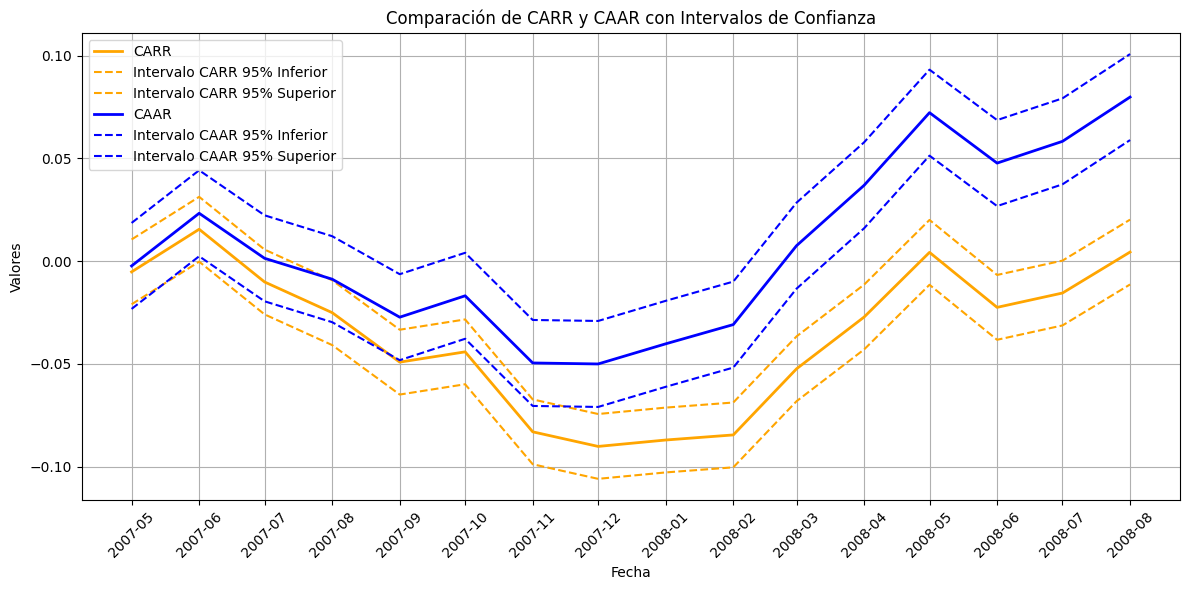

In [ ]:
# Configurar gráfico
plt.figure(figsize=(12, 6))

# Datos para plotear
plot_data = filtered_df.loc['2007-05-01':'2008-08-31']

# Gráfico para Raw Retornos (CARR)
plt.plot(plot_data.index, plot_data['spd_acm'], label='CARR', color='orange', linewidth=2)
plt.plot(plot_data.index, plot_data['inn'], label='Intervalo CARR 95% Inferior', color='orange', linestyle='--')
plt.plot(plot_data.index, plot_data['inp'], label='Intervalo CARR 95% Superior', color='orange', linestyle='--')

# Gráfico para Retornos Abnormales (CAAR)
plt.plot(plot_data.index, plot_data['spdRA_acm'], label='CAAR', color='blue', linewidth=2)
plt.plot(plot_data.index, plot_data['innRA'], label='Intervalo CAAR 95% Inferior', color='blue', linestyle='--')
plt.plot(plot_data.index, plot_data['inpRA'], label='Intervalo CAAR 95% Superior', color='blue', linestyle='--')

# Configuración de la leyenda
plt.legend()

# Título y etiquetas
plt.title('Comparación de CARR y CAAR con Intervalos de Confianza')
plt.xlabel('Fecha')
plt.ylabel('Valores')

# Formato del eje de las fechas
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)  # Rotar etiquetas para mejor lectura

# Mostrar el gráfico
plt.grid(True)
plt.tight_layout()
plt.show()